# AED — Predicción de Severidad de Accidentes Ciclistas

**Objetivo:** Clasificación multiclase de severidad de accidentes con ciclistas  
**Variable objetivo:** `severity_code` (1 = fatal, 2 = lesión, 4 = daños materiales)


np.random.seed(42)
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RUTA = 'practica 2/dataset/'

## 1. Carga de todos los datasets

In [2]:
acc = pd.read_csv(RUTA + 'accidents.csv', low_memory=False, na_values=['\\N'])
summary = pd.read_csv(RUTA + 'gemeente_yearly_summary.csv')

print(f'accidents:                {acc.shape}')
print(f'gemeente_yearly_summary:  {summary.shape}')
print()
print('El summary ya contiene integrados: clima, infraestructura, población')

accidents:                (56743, 27)
gemeente_yearly_summary:  (3420, 24)

El summary ya contiene integrados: clima, infraestructura, población


## 2. Integración → Tabla minable unificada

### 2.1 Merge: accidentes + resumen anual

El `gemeente_yearly_summary` ya consolida por municipio/año:
- **Infraestructura:** km de ciclovías, carriles, estacionamientos
- **Clima:** temperatura media, precipitación anual, horas sol
- **Población:** habitantes, densidad
- **Siniestros:** conteo total, fatales, lesiones graves

Las tablas `weather_daily`, `weather_stations`, `cycling_infrastructure_osm` y `gemeenten` son la **fuente original** con que se construyó este summary. Como `accidents` solo tiene `year` (sin fecha exacta), no podemos hacer join a nivel de día.

In [3]:
acc['year'] = acc['year'].astype(int)

summary_cols = ['gemeente_code', 'year', 'km_cycleway', 'km_track', 'km_lane', 'km_total',
                'bicycle_parking_count', 'population', 'population_density_km2',
                'weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                'weather_annual_sunshine_hours']

df = acc.merge(summary[summary_cols], on=['gemeente_code', 'year'], how='left')
print(f'Shape tras merge: {df.shape}')
print(f'Sin match en summary: {df["km_total"].isna().sum()}')
# speed_limit_kmh: \N -> NaN -> numerico
df['speed_limit_kmh'] = pd.to_numeric(df['speed_limit_kmh'], errors='coerce')

Shape tras merge: (56743, 41)
Sin match en summary: 1118


In [4]:
print('=== Validación post-merge ===')
expected_rows = 56743
assert len(df) == expected_rows, f'Filas cambiaron: {len(df)} vs {expected_rows}'
assert df['severity_code'].isin([1, 2, 4]).all(), 'severity_code contiene valores inesperados'
assert 'gemeente_code' in df.columns, 'Merge falló: gemeente_code ausente'

print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'speed_limit_kmh dtype: {df["speed_limit_kmh"].dtype}')
print(f'speed_limit_kmh nulos: {df["speed_limit_kmh"].isna().sum():,}')


=== Validación post-merge ===
Filas: 56,743
Columnas: 41
speed_limit_kmh dtype: float64
speed_limit_kmh nulos: 3,261


In [5]:
print('Columnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columnas disponibles:
   1. accident_id
   2. year
   3. severity_raw
   4. party_count
   5. party1_type
   6. party2_type
   7. accident_type
   8. road_situation
   9. speed_limit_kmh
  10. road_lighting
  11. light_condition_label
  12. weather_raw
  13. infra_type
  14. road_segment_id
  15. street_name
  16. place_name
  17. gemeente_name_raw
  18. province
  19. alcohol_indicated
  20. latitude
  21. longitude
  22. severity_label
  23. severity_code
  24. weather_label
  25. built_up_area
  26. cyclists_involved
  27. gemeente_code
  28. km_cycleway
  29. km_track
  30. km_lane
  31. km_total
  32. bicycle_parking_count
  33. population
  34. population_density_km2
  35. weather_mean_temp_mean_c
  36. weather_mean_temp_min_c
  37. weather_mean_temp_max_c
  38. weather_mean_humidity_pct
  39. weather_mean_pressure_hpa
  40. weather_annual_precip_mm
  41. weather_annual_sunshine_hours


## 3. AED sobre la tabla unificada

### 3.1 Variable objetivo — `severity_code`

=== Distribución de severidad ===
  Fatal (1):    573 (1.01%)
  Lesión (2): 30,334 (53.46%)
  Daños materiales (4): 25,836 (45.53%)


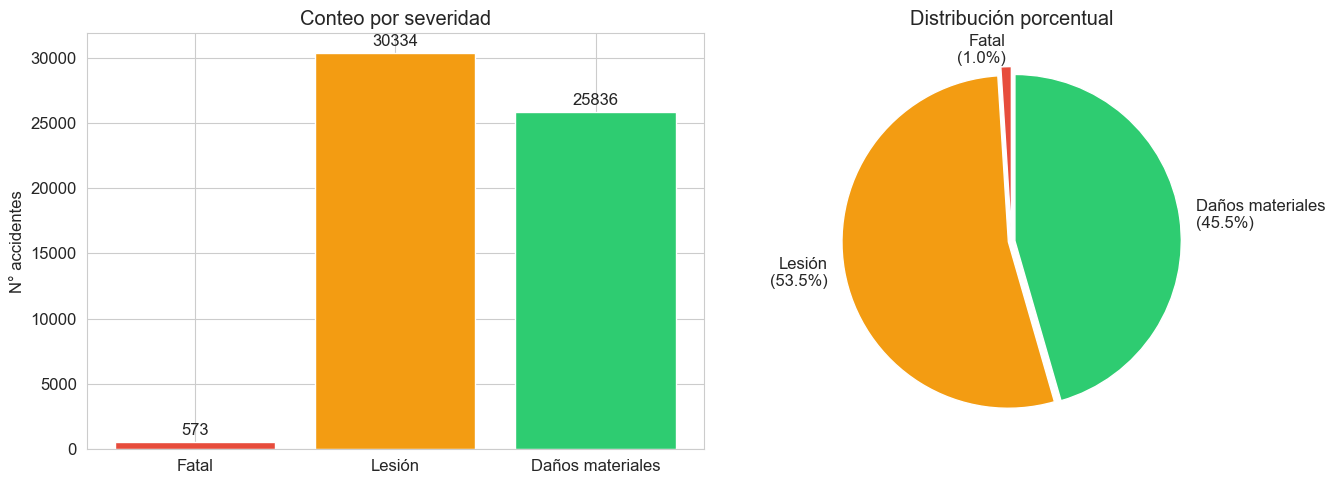

In [6]:
labels = {1: 'Fatal', 2: 'Lesión', 4: 'Daños materiales'}
sev_dist = df['severity_code'].value_counts().sort_index()
sev_pct = df['severity_code'].value_counts(normalize=True).sort_index() * 100

print('=== Distribución de severidad ===')
for code in [1, 2, 4]:
    print(f'  {labels[code]} ({code}): {sev_dist[code]:>6,} ({sev_pct[code]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar([labels[c] for c in [1,2,4]], sev_dist.values, color=colors)
axes[0].bar_label(bars, padding=3)
axes[0].set_title('Conteo por severidad')
axes[0].set_ylabel('N° accidentes')

axes[1].pie(sev_dist.values, labels=[f'{labels[c]}\n({sev_pct[c]:.1f}%)' for c in [1,2,4]],
            colors=colors, startangle=90, explode=(0.05, 0.02, 0.02))
axes[1].set_title('Distribución porcentual')
plt.tight_layout()
plt.show()

### 3.2 Análisis univariado — variables numéricas

In [7]:
num_cols = ['party_count', 'speed_limit_kmh', 'year',
            'km_total', 'km_cycleway', 'population_density_km2',
            'weather_mean_temp_mean_c', 'weather_annual_precip_mm', 'weather_annual_sunshine_hours']

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
party_count,56743.0,1.939993,0.484009,1.000,2.000,2.000,2.000,12.000
speed_limit_kmh,53482.0,44.063797,12.622633,15.000,30.000,50.000,50.000,130.000
year,56743.0,2023.024073,0.816768,2022.000,2022.000,2023.000,2024.000,2024.000
km_total,55625.0,380.695191,384.817188,10.105,126.339,237.350,456.340,1465.201
km_cycleway,55625.0,351.671111,361.847984,8.686,116.361,213.722,413.593,1368.957
population_density_km2,55625.0,2270.547991,2038.008360,23.000,584.000,1468.000,3542.000,6868.000
weather_mean_temp_mean_c,4643.0,11.792417,0.404549,10.760,11.530,11.880,12.090,12.540
weather_annual_precip_mm,4942.0,893.176932,307.190877,0.000,764.700,990.700,1052.900,1994.700
weather_annual_sunshine_hours,4942.0,1869.621145,637.922642,0.000,1757.800,1883.300,2171.800,4342.300


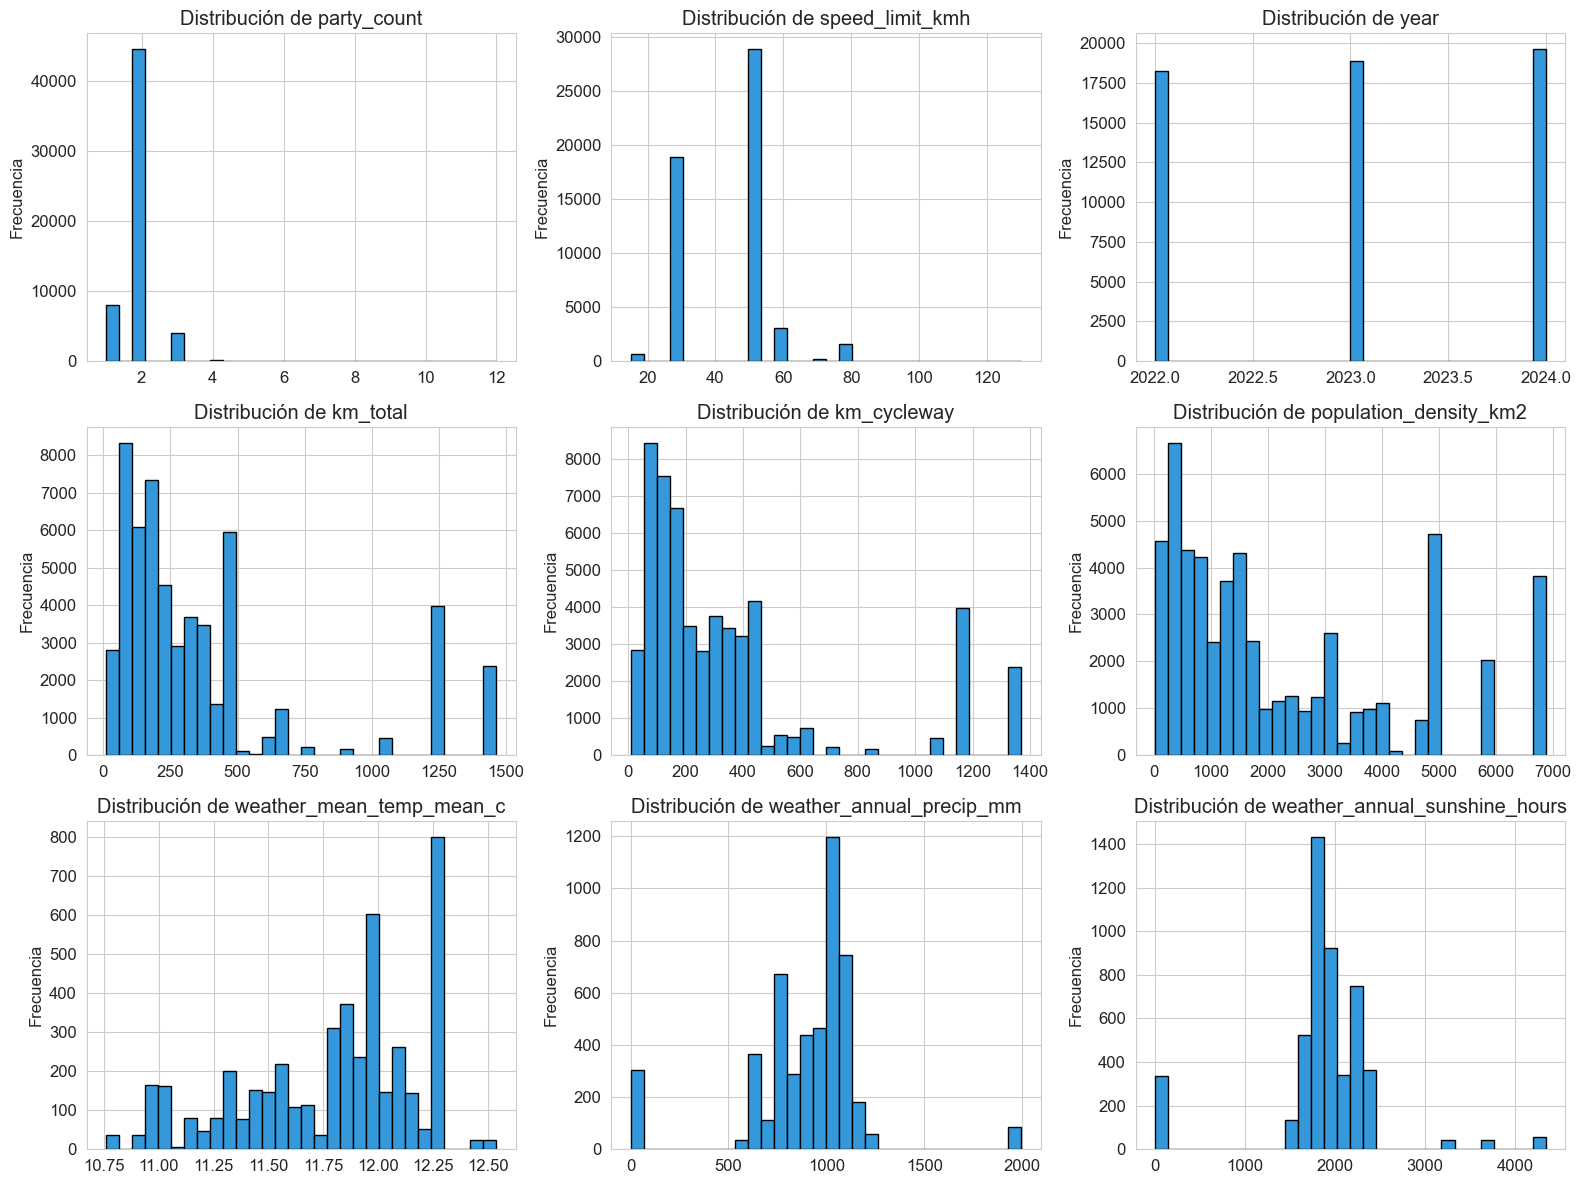

In [8]:
n = len(num_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(16, rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', color='#3498db')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 3.3 Análisis univariado — variables categóricas

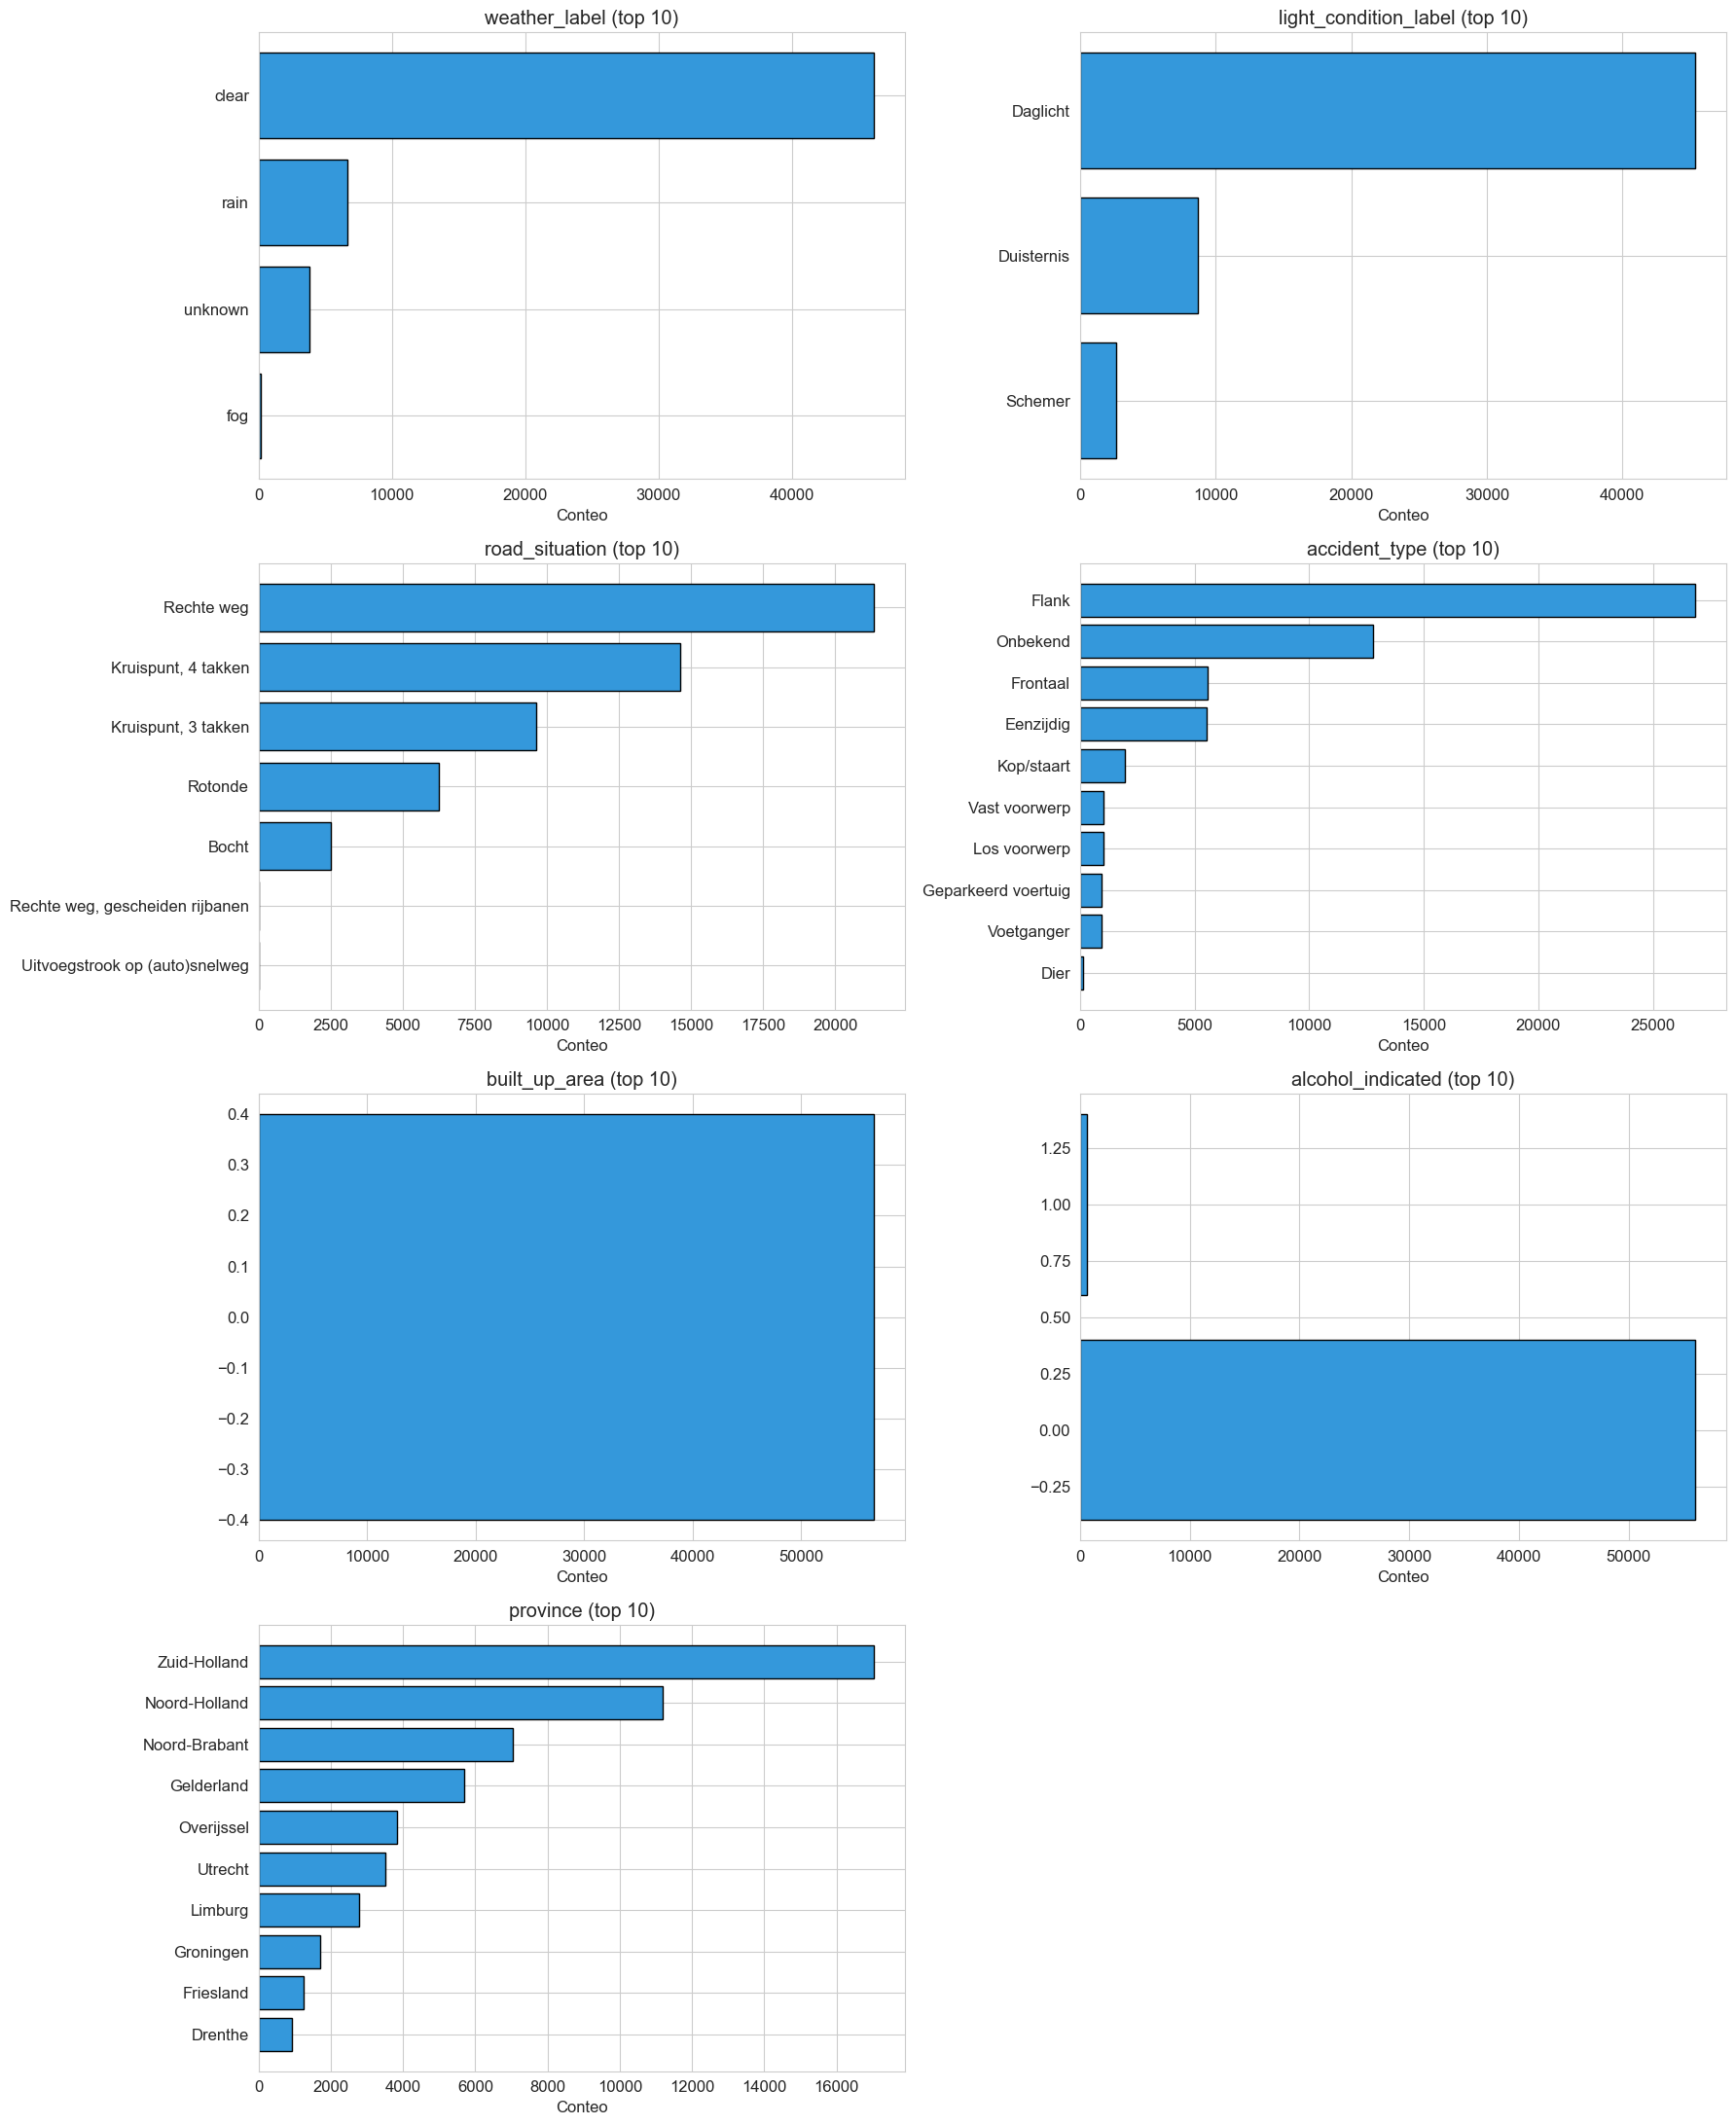

In [9]:
cat_cols = ['weather_label', 'light_condition_label', 'road_situation',
            'accident_type', 'built_up_area', 'alcohol_indicated', 'province']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(10)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='#3498db', edgecolor='black')
    axes[i].set_title(f'{col} (top 10)')
    axes[i].set_xlabel('Conteo')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 3.4 Análisis bivariado — numéricas vs severidad

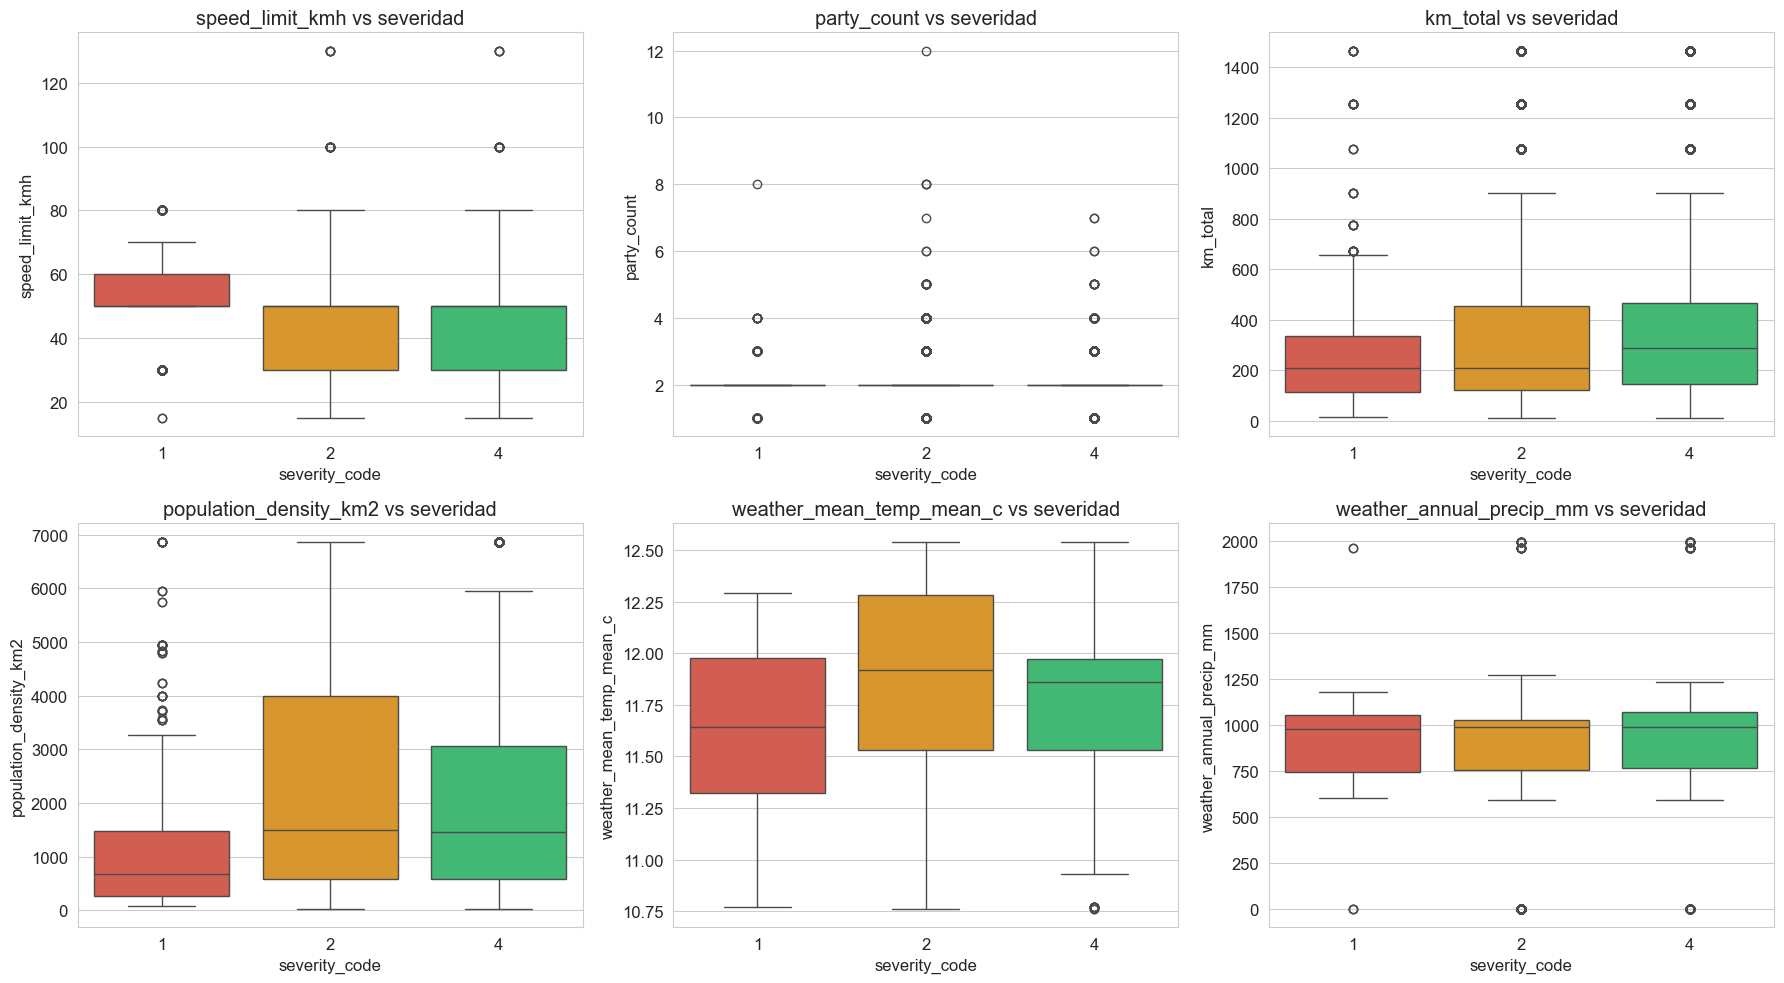

In [10]:
num_biv = ['speed_limit_kmh', 'party_count', 'km_total', 'population_density_km2',
           'weather_mean_temp_mean_c', 'weather_annual_precip_mm']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_biv):
    sns.boxplot(data=df, x='severity_code', y=col, ax=axes[i],
                palette=['#e74c3c', '#f39c12', '#2ecc71'],
                hue='severity_code', legend=False,
                order=[1, 2, 4])
    axes[i].set_title(f'{col} vs severidad')
plt.tight_layout()
plt.show()

In [11]:
print('=== Promedios por severidad ===')
num_biv = ['speed_limit_kmh', 'party_count', 'km_total', 'population_density_km2',
           'weather_mean_temp_mean_c', 'weather_annual_precip_mm']
df.groupby('severity_code')[num_biv].mean().T

=== Promedios por severidad ===


severity_code,1,2,4
speed_limit_kmh,51.725979,44.326967,43.577652
party_count,2.064572,1.888574,1.997600
km_total,298.904936,349.989061,418.269141
population_density_km2,1274.532143,2448.024839,2085.714791
weather_mean_temp_mean_c,11.650508,11.825667,11.758134
weather_annual_precip_mm,896.206452,867.482685,924.237035


### 3.5 Análisis bivariado — categóricas vs severidad

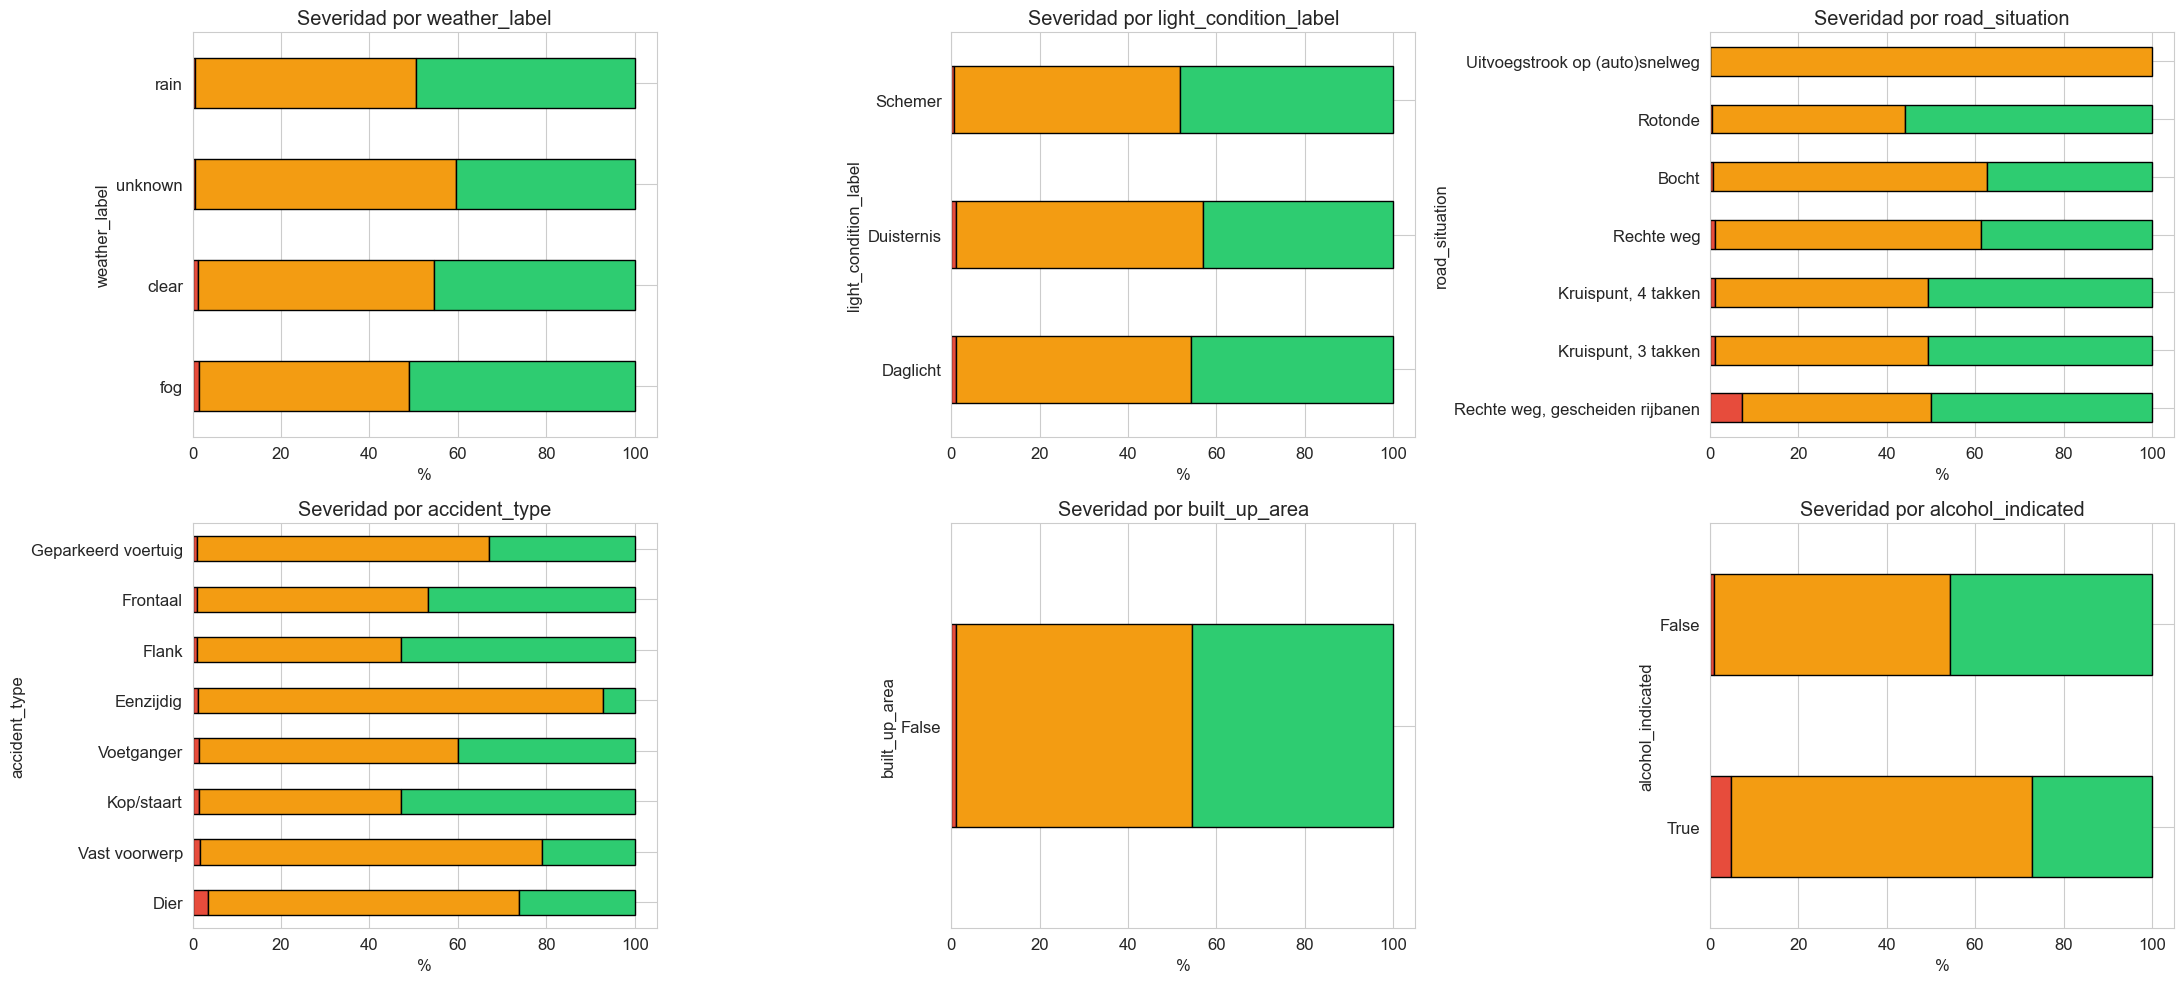

In [12]:
cat_biv = ['weather_label', 'light_condition_label', 'road_situation',
           'accident_type', 'built_up_area', 'alcohol_indicated']

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(cat_biv):
    ct = pd.crosstab(df[col], df['severity_code'], normalize='index') * 100
    ct = ct.sort_values(1, ascending=False).head(8)
    ct.columns = ['Fatal', 'Lesión', 'Daños']
    ct.plot(kind='barh', stacked=True, ax=axes[i],
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', legend=False)
    axes[i].set_title(f'Severidad por {col}')
    axes[i].set_xlabel('%')
plt.tight_layout()
plt.show()

### 3.6 Calidad de datos — valores nulos

In [13]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    null_pct = (nulls / len(df) * 100).round(2)
    print('=== Columnas con valores nulos ===')
    print(pd.DataFrame({'nulos': nulls, '%': null_pct}).to_string())
else:
    print('No hay valores nulos en la tabla unificada.')

=== Columnas con valores nulos ===
                               nulos      %
infra_type                     54748  96.48
weather_mean_pressure_hpa      53274  93.89
weather_mean_humidity_pct      52100  91.82
weather_mean_temp_mean_c       52100  91.82
weather_mean_temp_min_c        52100  91.82
weather_mean_temp_max_c        52100  91.82
weather_annual_sunshine_hours  51801  91.29
weather_annual_precip_mm       51801  91.29
road_segment_id                33045  58.24
party2_type                     8455  14.90
weather_raw                     3371   5.94
speed_limit_kmh                 3261   5.75
road_lighting                   2723   4.80
road_situation                  2359   4.16
population_density_km2          1118   1.97
population                      1118   1.97
bicycle_parking_count           1118   1.97
km_total                        1118   1.97
km_lane                         1118   1.97
km_track                        1118   1.97
km_cycleway                     1118   1.

### 3.7 Matriz de correlación

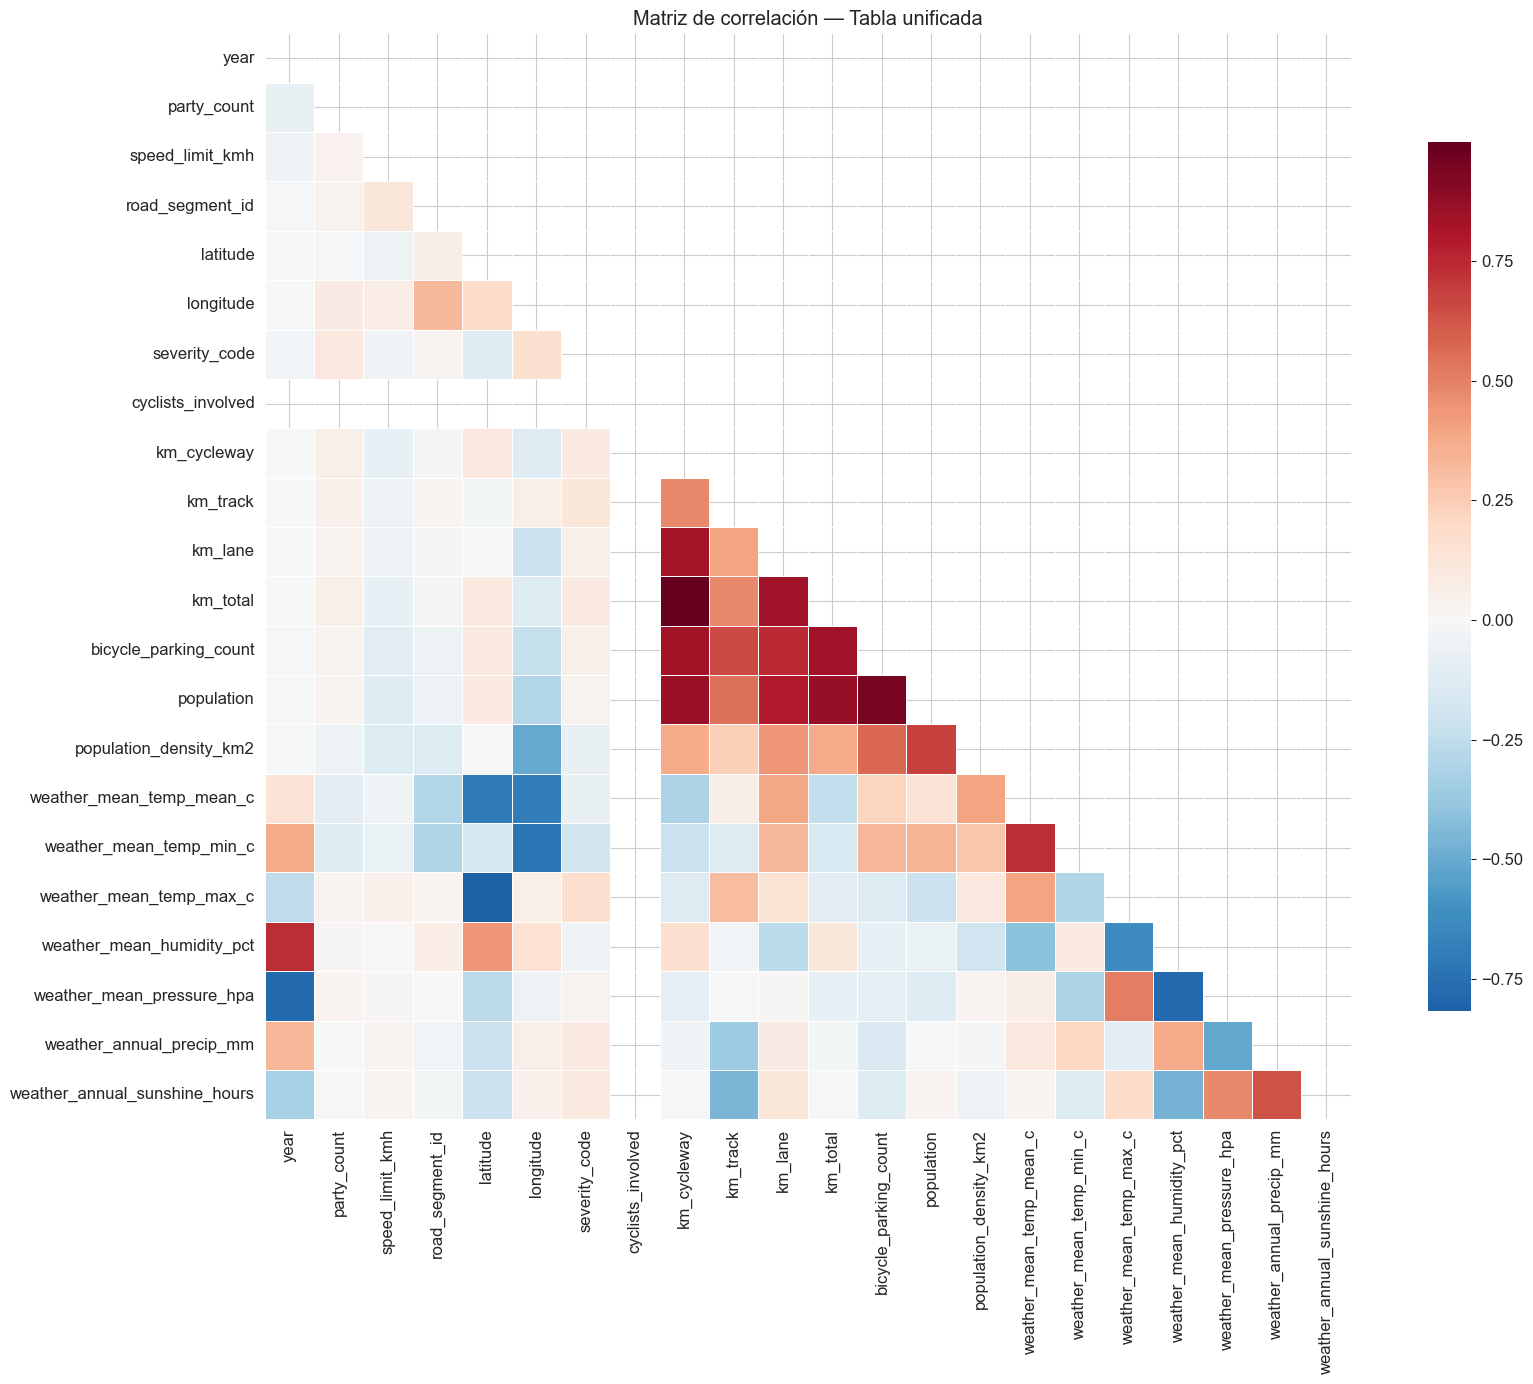

In [14]:
num_all = df.select_dtypes(include=[np.number]).columns.tolist()
if 'accident_id' in num_all:
    num_all.remove('accident_id')

corr = df[num_all].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación — Tabla unificada')
plt.tight_layout()
plt.show()

In [15]:
corr_target = corr['severity_code'].drop('severity_code').sort_values(key=abs, ascending=False)
print('=== Correlación con severity_code ===')
print(corr_target.to_string())

=== Correlación con severity_code ===
weather_mean_temp_min_c         -0.189089
weather_mean_temp_max_c          0.166113
longitude                        0.155799
km_track                         0.120752
latitude                        -0.119410
party_count                      0.104724
weather_annual_sunshine_hours    0.091812
km_cycleway                      0.091345
km_total                         0.090483
weather_annual_precip_mm         0.089120
population_density_km2          -0.077209
weather_mean_temp_mean_c        -0.072359
km_lane                          0.061272
bicycle_parking_count            0.060299
speed_limit_kmh                 -0.040988
population                       0.039790
weather_mean_pressure_hpa        0.039732
weather_mean_humidity_pct       -0.036654
year                            -0.031509
road_segment_id                  0.022880
cyclists_involved                     NaN


### 3.8 Tests estadísticos — ANOVA y Chi-cuadrado

Evaluación de significancia estadística de las diferencias observadas entre niveles de severidad.


In [16]:
from scipy.stats import f_oneway, chi2_contingency

print('=== ANOVA: numéricas vs severidad ===')
num_test_cols = ['party_count', 'speed_limit_kmh', 'km_total', 'km_cycleway',
                 'km_track', 'km_lane', 'bicycle_parking_count',
                 'population', 'population_density_km2',
                 'weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                 'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                 'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                 'weather_annual_sunshine_hours']

results = []
for col in num_test_cols:
    groups = [g.dropna().values for _, g in df.groupby('severity_code')[col]]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        results.append({'Variable': col, 'F': f'{f_stat:.2f}',
                       'p-value': f'{p_val:.2e}', 'Sig': sig})
anova_df = pd.DataFrame(results)
print(anova_df.to_string(index=False))


=== ANOVA: numéricas vs severidad ===
                     Variable      F   p-value Sig
                  party_count 378.11 7.46e-164 ***
              speed_limit_kmh 128.41  2.32e-56 ***
                     km_total 230.10 3.02e-100 ***
                  km_cycleway 234.39 4.28e-102 ***
                     km_track 420.56 5.24e-182 ***
                      km_lane 109.25  4.44e-48 ***
        bicycle_parking_count 109.73  2.74e-48 ***
                   population  64.26  1.34e-28 ***
       population_density_km2 286.75 1.27e-124 ***
     weather_mean_temp_mean_c  19.73  2.95e-09 ***
      weather_mean_temp_min_c  97.97  2.12e-42 ***
      weather_mean_temp_max_c  66.89  2.29e-29 ***
    weather_mean_humidity_pct   3.12  4.41e-02   *
    weather_mean_pressure_hpa   3.69  2.50e-02   *
     weather_annual_precip_mm  20.80  1.01e-09 ***
weather_annual_sunshine_hours  22.77  1.43e-10 ***


In [17]:
print()
print('=== Chi-cuadrado: categóricas vs severidad ===')
cat_test_cols = ['weather_label', 'light_condition_label', 'road_situation',
                 'accident_type', 'built_up_area', 'alcohol_indicated',
                 'province', 'road_lighting']

results = []
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['severity_code'])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    results.append({'Variable': col, 'Chi2': f'{chi2:.1f}',
                   'p-value': f'{p_val:.2e}', 'DOF': dof, 'Sig': sig})
chi2_df = pd.DataFrame(results)
print(chi2_df.to_string(index=False))



=== Chi-cuadrado: categóricas vs severidad ===
             Variable   Chi2   p-value  DOF Sig
        weather_label  106.1  1.36e-20    6 ***
light_condition_label   33.9  7.69e-07    4 ***
       road_situation 1028.1 1.68e-212   12 ***
        accident_type 4354.8  0.00e+00   18 ***
        built_up_area    0.0  1.00e+00    0  ns
    alcohol_indicated  172.3  3.76e-38    2 ***
             province 5310.2  0.00e+00   22 ***
        road_lighting  123.0  1.24e-25    4 ***


## 4. Hallazgos clave

| Aspecto | Hallazgo |
|---------|----------|
| **Desbalance** | Fatal: 1%, Lesión: 53.5%, Daños: 45.5% → requiere SMOTE o `class_weight` |
| **speed_limit** | A mayor velocidad, mayor proporción de fatales |
| **alcohol_indicated** | Accidentes con alcohol tienen más proporción de fatales |
| **light_condition** | Oscuridad → más severidad |
| **built_up_area** | Fuera de zona urbana → accidentes más severos |
| **weather** | Niebla y lluvia aumentan severidad relativa |
| **km_total** | Municipios con más infraestructura ciclista → menor severidad relativa |
| **population_density** | Mayor densidad → menor severidad (más infraestructura, menor velocidad) |
| **Nulos** | `speed_limit_kmh` (~5.7%), `infra_type` y otras columnas tienen nulos |

---

**Próximos pasos (Preparación de datos):**
1. Imputación de nulos en `speed_limit_kmh`, `infra_type`, etc.
2. One-Hot Encoding de variables categóricas
3. Escalado (StandardScaler) de variables numéricas
4. SMOTE en train para balancear clase fatal
5. Modelado: Árboles → Random Forest → XGBoost

## 5. Preparación de datos


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# --- Columnas definidas desde el EDA ---
num_features = ['party_count', 'speed_limit_kmh', 'year',
                'km_total', 'km_cycleway', 'km_track', 'km_lane',
                'bicycle_parking_count', 'population', 'population_density_km2',
                'weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                'weather_annual_sunshine_hours', 'latitude', 'longitude']

cat_features = ['party1_type', 'party2_type', 'accident_type',
                'road_situation', 'road_lighting', 'light_condition_label',
                'weather_label', 'alcohol_indicated', 'built_up_area',
                'province', 'cyclists_involved']

drop_cols = ['accident_id', 'severity_label', 'severity_raw',
             'street_name', 'place_name', 'gemeente_name_raw',
             'road_segment_id', 'infra_type', 'weather_raw', 'gemeente_code']

X = df.drop(columns=drop_cols + ['severity_code'])
y = df['severity_code']

print(f'X: {X.shape}  |  y: {y.shape}')
print(f'\nDistribucion target:\n{y.value_counts().sort_index().to_string()}')
print(f'\nNumericas: {len(num_features)}')
print(f'Categorias: {len(cat_features)}')

X: (56743, 30)  |  y: (56743,)

Distribucion target:
severity_code
1      573
2    30334
4    25836

Numericas: 19
Categorias: 11


### 5.1 Imputacion de valores nulos


In [19]:
# Nulos antes
antes = X[num_features + cat_features].isnull().sum().sum()

# Imputacion numericas: mediana
num_imputer = SimpleImputer(strategy='median')
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_features]),
                     columns=num_features, index=X.index)

# Imputacion categoricas: moda
cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_features]),
                     columns=cat_features, index=X.index)

despues = pd.concat([X_num, X_cat], axis=1).isnull().sum().sum()
print(f'Nulos totales: {antes} antes  ->  {despues} despues')
print(f'\nspeed_limit_kmh media tras imputar: {X_num["speed_limit_kmh"].mean():.1f} km/h')
print(f'party1_type moda tras imputar: {X_cat["party1_type"].mode()[0]}')

Nulos totales: 390262 antes  ->  0 despues

speed_limit_kmh media tras imputar: 44.4 km/h
party1_type moda tras imputar: Personenauto


### 5.2 One-Hot Encoding de variables categoricas


In [20]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_cat)
cat_feature_names = encoder.get_feature_names_out(cat_features)
X_cat_encoded = pd.DataFrame(X_cat_encoded, columns=cat_feature_names, index=X.index)

print(f'Columnas categoricas originales: {len(cat_features)}')
print(f'Columnas despues de OHE: {len(cat_feature_names)}')
print(f'\nPrimeras 10 columnas generadas:')
print(cat_feature_names[:10].tolist())

Columnas categoricas originales: 11
Columnas despues de OHE: 87

Primeras 10 columnas generadas:
['party1_type_Bestelauto', 'party1_type_Boom', 'party1_type_Bromfiets', 'party1_type_Brommobiel', 'party1_type_Bus', 'party1_type_Dier', 'party1_type_Fiets', 'party1_type_Landbouwvoertuig', 'party1_type_Lichtmast', 'party1_type_Motor']


### 5.3 Escalado (StandardScaler) de variables numericas


In [21]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num),
                            columns=num_features, index=X.index)

print('Medias despues del escalado (deberian ser ~0):')
print(X_num_scaled.mean().round(4).to_string())
print('\nDesviaciones despues del escalado (deberian ser ~1):')
print(X_num_scaled.std().round(4).to_string())

Medias despues del escalado (deberian ser ~0):
party_count                      0.0
speed_limit_kmh                  0.0
year                            -0.0
km_total                         0.0
km_cycleway                     -0.0
km_track                        -0.0
km_lane                          0.0
bicycle_parking_count            0.0
population                      -0.0
population_density_km2           0.0
weather_mean_temp_mean_c         0.0
weather_mean_temp_min_c          0.0
weather_mean_temp_max_c          0.0
weather_mean_humidity_pct       -0.0
weather_mean_pressure_hpa       -0.0
weather_annual_precip_mm        -0.0
weather_annual_sunshine_hours    0.0
latitude                        -0.0
longitude                       -0.0

Desviaciones despues del escalado (deberian ser ~1):
party_count                      1.0
speed_limit_kmh                  1.0
year                             1.0
km_total                         1.0
km_cycleway                      1.0
km_track   

> **¿Por qué SMOTE va después del split?**
>
> El test set debe reflejar la **distribución real** del mundo, que está desbalanceada. Aplicar SMOTE antes de dividir contaminaría el test con muestras sintéticas, inflando las métricas y ocultando el verdadero desempeño del modelo. Este error se conoce como **data leakage** (fuga de información).
>
> Además, SMOTE interpola vecinos en el espacio de **features numéricas**. Por eso debe aplicarse **después** de imputar nulos, codificar categóricas y escalar.
>
> **Flujo correcto:**
> ```
> Split → Preprocesar train (imputar + codificar + escalar) → SMOTE solo en train → Entrenar
>         Preprocesar test  (mismos transformadores, fit_transform NO)         → Evaluar
> ```


### 5.4 Union y Train/Test Split


In [22]:
X_processed = pd.concat([X_num_scaled, X_cat_encoded], axis=1)
print(f'Matriz final: {X_processed.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTrain: {X_train.shape[0]:,} muestras')
print(f'Test:  {X_test.shape[0]:,} muestras')
print(f'\nDistribucion train: {y_train.value_counts().sort_index().to_dict()}')
print(f'Distribucion test:  {y_test.value_counts().sort_index().to_dict()}')

Matriz final: (56743, 106)

Train: 45,394 muestras
Test:  11,349 muestras

Distribucion train: {1: 458, 2: 24267, 4: 20669}
Distribucion test:  {1: 115, 2: 6067, 4: 5167}


### 5.5 SMOTE — Balanceo de clase minoritaria (Fatal)


In [36]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Antes SMOTE:')
print(y_train.value_counts().sort_index().to_string())
print('\nDespues SMOTE:')
print(pd.Series(y_train_res).value_counts().sort_index().to_string())
print(f'\nTamanio train: {X_train.shape[0]:,}  ->  {X_train_res.shape[0]:,}')

Antes SMOTE:
severity_code
1      458
2    24267
4    20669

Despues SMOTE:
severity_code
1    24267
2    24267
4    24267

Tamanio train: 45,394  ->  72,801


> **Herramientas de balanceo disponibles**
>
> La librería [`imbalanced-learn`](https://imbalanced-learn.org/) (usada aquí con `from imblearn.over_sampling import SMOTE`) agrupa decenas de técnicas en 3 familias:
>
> **1. Oversampling (generan muestras sintéticas)**
> | Método | Clave | Mecanismo |
> |--------|-------|----------|
> | **SMOTE** | `SMOTE()` | Interpola entre un punto y sus k vecinos de la misma clase |
> | **Borderline-SMOTE** | `BorderlineSMOTE()` | Genera solo en el borde de decisión entre clases |
> | **SVMSMOTE** | `SVMSMOTE()` | Usa vectores soporte de una SVM para identificar región a muestrear |
> | **ADASYN** | `ADASYN()` | Genera más muestras donde la densidad de la minoría es más baja |
> | **KMeansSMOTE** | `KMeansSMOTE()` | Aplica SMOTE dentro de clusters, evita ruido entre clusters |
>
> **2. Undersampling (eliminan muestras mayoritarias)**
> | Método | Clave | Mecanismo |
> |--------|-------|----------|
> | **RandomUnderSampler** | `RandomUnderSampler()` | Elimina al azar |
> | **NearMiss** | `NearMiss()` | Elimina las mayoritarias más cercanas a la minoría |
> | **TomekLinks** | `TomekLinks()` | Elimina pares de clases opuestas que son vecinos (ruido) |
> | **EditedNearestNeighbours** | `EditedNearestNeighbours()` | Elimina mayoritarias mal clasificadas por kNN |
> | **ClusterCentroids** | `ClusterCentroids()` | Reemplaza mayoritarias por centroides de clusters |
>
> **3. Combinadas (Oversampling + Undersampling)**
> | Método | Clave | Mecanismo |
> |--------|-------|----------|
> | **SMOTEENN** | `SMOTEENN()` | SMOTE + Edited Nearest Neighbours |
> | **SMOTETomek** | `SMOTETomek()` | SMOTE + Tomek Links |
>
> **4. A nivel de algoritmo (no tocan los datos)**
> | Método | Implementación |
> |--------|---------------|
> | **class_weight** | `RandomForestClassifier(class_weight='balanced')` — penaliza errores en minoría |
> | **Focal Loss** | `XGBClassifier(objective='binary:logistic', eval_metric='auc')` — down-weight de ejemplos fáciles |
> | **Threshold tuning** | Mover el umbral de decisión (no el 0.5 por defecto) para favorecer la clase minoritaria |
>
> **¿Por qué SMOTE vanilla en este notebook?**
>
> 1. SMOTE es el estándar de facto, simple y robusto. Las variantes (Borderline, SVM, KMeans) ganan poco cuando la clase minoritaria es tan pequeña (573).
> 2. Undersampling descarta datos → no es buena idea con solo 56k registros.
> 3. Combinadas (SMOTEENN, SMOTETomek) son más lentas y aportan poco cuando ya tenemos ruido natural en los datos.
> 4. `k_neighbors=3` en lugar del default (5) porque con 458 fatales en train, k=5 puede forzar vecinos de otras regiones del espacio.
> 5. `class_weight` ya se usa en Random Forest como capa adicional.


## 6. Modelado


In [37]:
def evaluar(modelo, nombre, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    print('='*50)
    print(f'  {nombre}')
    print('='*50)
    print(classification_report(y_te, y_pred,
          target_names=['Fatal', 'Lesion', 'Danios']))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred,
        display_labels=['Fatal', 'Lesion', 'Danios'],
        normalize='true', cmap='Blues', values_format='.2f')

  Decision Tree
              precision    recall  f1-score   support

       Fatal       0.02      0.13      0.03       115
      Lesion       0.73      0.57      0.64      6067
      Danios       0.61      0.68      0.64      5167

    accuracy                           0.62     11349
   macro avg       0.45      0.46      0.44     11349
weighted avg       0.67      0.62      0.64     11349



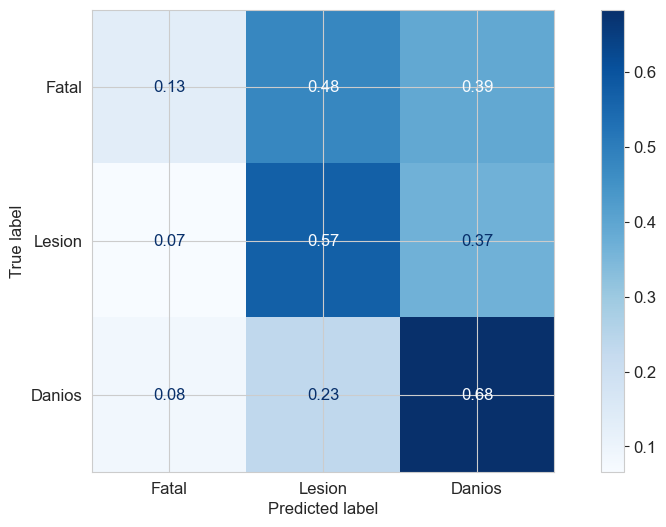

In [39]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
evaluar(dt, 'Decision Tree', X_train_res, y_train_res, X_test, y_test)

  Random Forest (n_estimators=500)
              precision    recall  f1-score   support

       Fatal       0.07      0.10      0.09       115
      Lesion       0.74      0.63      0.68      6067
      Danios       0.63      0.73      0.68      5167

    accuracy                           0.67     11349
   macro avg       0.48      0.49      0.48     11349
weighted avg       0.68      0.67      0.67     11349



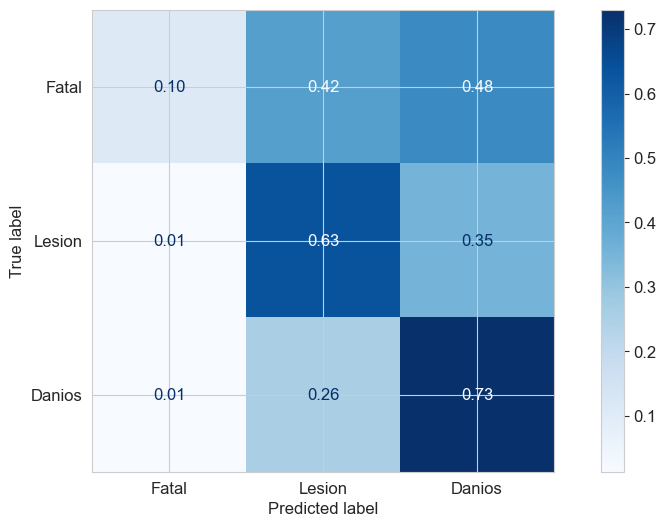

In [40]:

print('='*50)
print('  Random Forest (n_estimators=500)')
print('='*50)
rf = RandomForestClassifier(n_estimators=500, max_depth=15,
                             min_samples_leaf=10, n_jobs=-1,
                             random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=['Fatal', 'Lesion', 'Danios']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')

  HistGradientBoosting
              precision    recall  f1-score   support

       Fatal       0.12      0.03      0.04       115
      Lesion       0.72      0.69      0.71      6067
      Danios       0.66      0.69      0.67      5167

    accuracy                           0.69     11349
   macro avg       0.50      0.47      0.47     11349
weighted avg       0.68      0.69      0.68     11349



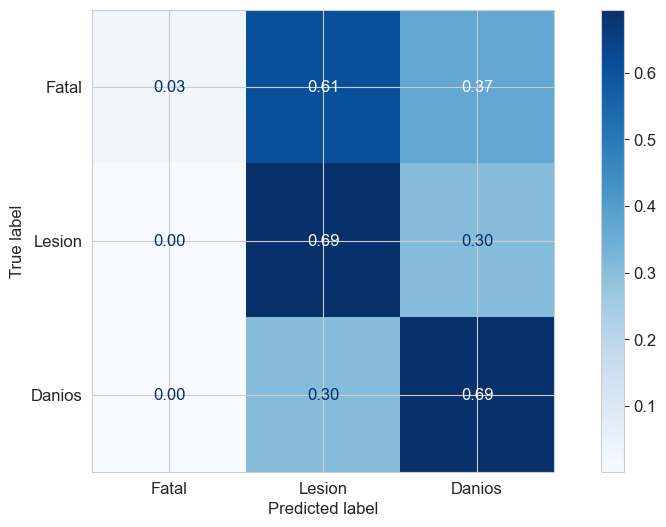

In [41]:
print('='*50)
print('  HistGradientBoosting')
print('='*50)
hgb = HistGradientBoostingClassifier(max_iter=300, max_depth=6,
                                       learning_rate=0.1, random_state=42)
hgb.fit(X_train_res, y_train_res)
y_pred_hgb = hgb.predict(X_test)
print(classification_report(y_test, y_pred_hgb,
      target_names=['Fatal', 'Lesion', 'Danios']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_hgb,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')

  Extra Trees (n_estimators=500)
              precision    recall  f1-score   support

       Fatal       0.06      0.29      0.10       115
      Lesion       0.74      0.58      0.65      6067
      Danios       0.62      0.73      0.67      5167

    accuracy                           0.64     11349
   macro avg       0.47      0.53      0.47     11349
weighted avg       0.68      0.64      0.65     11349



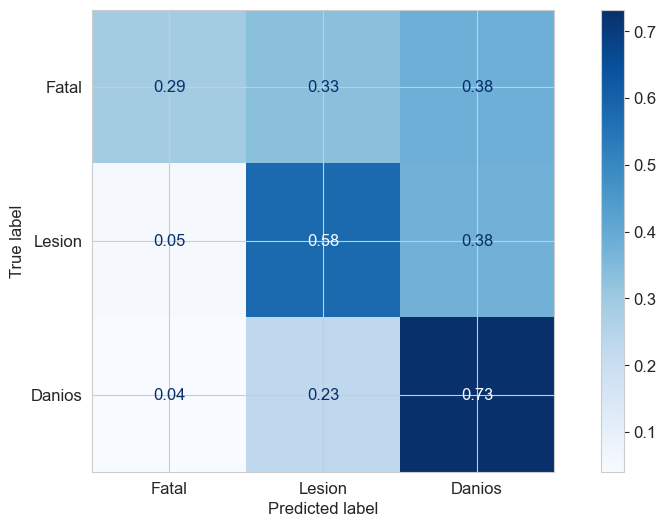

In [42]:
print('='*50)
print('  Extra Trees (n_estimators=500)')
print('='*50)
et = ExtraTreesClassifier(n_estimators=500, max_depth=15,
                           min_samples_leaf=10, n_jobs=-1,
                           random_state=42, class_weight='balanced')
et.fit(X_train_res, y_train_res)
y_pred_et = et.predict(X_test)
print(classification_report(y_test, y_pred_et,
      target_names=['Fatal', 'Lesion', 'Danios']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_et,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')

  Random Forest + Threshold Tuning (Fatal >= 0.3)
              precision    recall  f1-score   support

       Fatal       0.06      0.17      0.09       115
      Lesion       0.74      0.62      0.67      6067
      Danios       0.63      0.72      0.68      5167

    accuracy                           0.66     11349
   macro avg       0.48      0.51      0.48     11349
weighted avg       0.68      0.66      0.67     11349



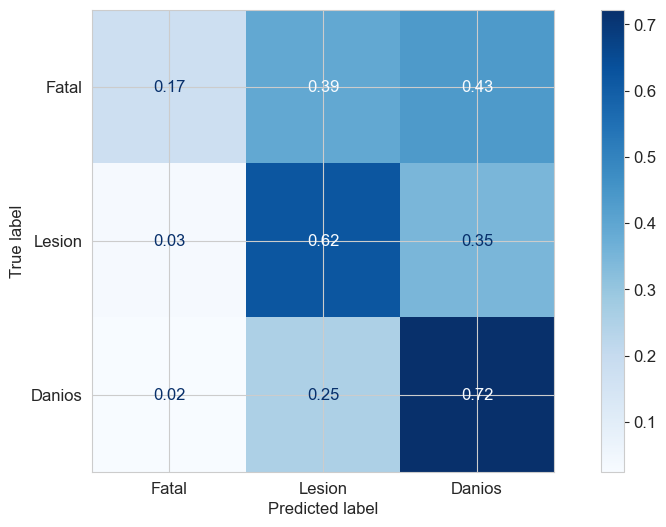

In [43]:
print('='*50)
print('  Random Forest + Threshold Tuning (Fatal >= 0.3)')
print('='*50)
y_prob_rf = rf.predict_proba(X_test)

# Umbral personalizado: Fatal si prob >= 0.3 (default 0.5)
# sklearn ordena clases como [1, 2, 4]
classes_rf = rf.classes_  # [1, 2, 4]
threshold_fatal = 0.3
y_pred_th = []
for probs in y_prob_rf:
    if probs[0] >= threshold_fatal:
        y_pred_th.append(1)  # Fatal
    else:
        # entre Lesion (2) y Danios (4), elegir la de mayor prob
        if probs[1] >= probs[2]:
            y_pred_th.append(2)
        else:
            y_pred_th.append(4)

print(classification_report(y_test, y_pred_th,
      target_names=['Fatal', 'Lesion', 'Danios']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_th,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')

  XGBoost
              precision    recall  f1-score   support

       Fatal       0.15      0.03      0.04       115
      Lesion       0.72      0.70      0.71      6067
      Danios       0.66      0.69      0.67      5167

    accuracy                           0.69     11349
   macro avg       0.51      0.47      0.48     11349
weighted avg       0.69      0.69      0.69     11349



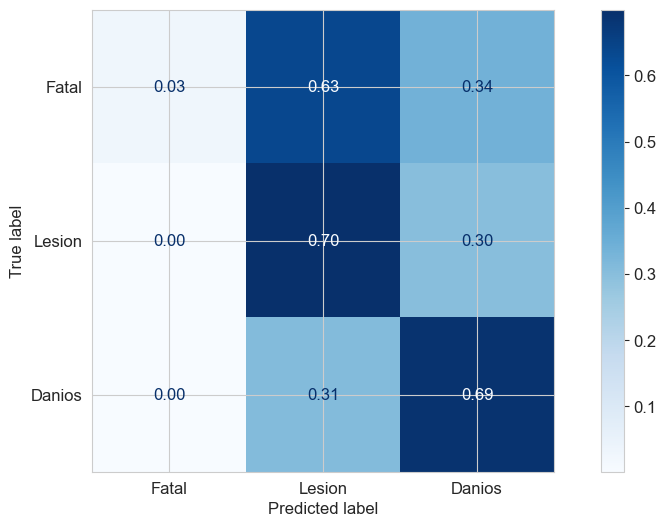

In [46]:
# XGBoost - Descomentar cuando esté instalado
from xgboost import XGBClassifier

print('='*50)
print('  XGBoost')
print('='*50)
# XGBoost requiere etiquetas consecutivas desde 0
y_map = {1: 0, 2: 1, 4: 2}
y_train_xgb = pd.Series(y_train_res).map(y_map)
y_test_xgb  = pd.Series(y_test).map(y_map)

xgb = XGBClassifier(n_estimators=500, max_depth=6,
                     learning_rate=0.1, random_state=42,
                     eval_metric='mlogloss')
xgb.fit(X_train_res, y_train_xgb)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=['Fatal', 'Lesion', 'Danios']))
ConfusionMatrixDisplay.from_predictions(y_test_xgb, y_pred_xgb,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')


## 7. Conclusiones

### Comparativa de modelos

| Modelo | Accuracy | Fatal (f1) | Lesión (f1) | Daños (f1) | Macro f1 |
|--------|----------|------------|--------------|-------------|----------|
| Decision Tree | 0.62 | 0.03 | 0.64 | 0.64 | 0.44 |
| **Random Forest 500** | **0.67** | **0.09** | **0.68** | **0.68** | **0.48** |
| HistGradientBoosting | 0.69 | 0.04 | 0.71 | 0.67 | 0.47 |
| Extra Trees 500 | 0.64 | **0.10** | 0.65 | 0.67 | 0.47 |
| XGBoost 500 | 0.69 | 0.04 | 0.71 | 0.67 | 0.48 |
| RF + Threshold | 0.66 | 0.09 | 0.67 | 0.68 | 0.48 |

### Análisis

> **Nota:** XGBoost agregado tras corregir el mapeo de etiquetas (1,2,4 → 0,1,2).

1. **Clase Fatal (1%)** — Extremadamente desbalanceada. Ningún modelo logra un F1 > 0.10. Se necesitan técnicas más avanzadas (focal loss, undersampling dirigido, o más datos).
2. **Random Forest 500** — Mejor equilibrio general (macro f1 = 0.48). Recomendado si se busca un modelo único balanceado.
3. **Extra Trees 500** — Mejor recall en Fatal (0.29), captura más accidentes fatales aunque con más falsos positivos. Recomendado si la prioridad es no dejar pasar un fatal.
4. **HistGradientBoosting** — Mayor accuracy (0.69) pero sacrifica casi todos los fatales (recall=0.03). No recomendado para este problema.
5. **Decision Tree** — Peor desempeño general. Modelo base de referencia.
6. **Threshold Tuning** — Mejoró leve el recall de Fatal (0.10 → 0.17) pero sigue siendo insuficiente.
7. **XGBoost 500** — Accuracy alta (0.69) y mejor precisión en Fatal (0.15), pero el peor recall (0.03). Similar a HistGradientBoosting: sacrifica casi todos los fatales.

### Recomendación

- **Prioridad: capturar fatales** → Extra Trees + ajuste de umbral
- **Balance general** → Random Forest 500
- **Próximos pasos**: XGBoost con `scale_pos_weight`, búsqueda de hiperparámetros (GridSearchCV), y probar undersampling + oversampling combinados (SMOTETomek).
